# Library

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_curve
from sklearn.metrics import recall_score, classification_report, auc, roc_curve
from sklearn.metrics import precision_recall_fscore_support, f1_score
from sklearn.preprocessing import StandardScaler
from pylab import rcParams
from keras.models import Model, load_model
from keras.layers import Input, Dense
from keras.callbacks import ModelCheckpoint, TensorBoard
from keras import regularizers

# Read Dataset

In [ ]:
df = pd.read_csv("creditcard.csv")

In [ ]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
#cek data kosong
df.isnull().values.sum()

0

In [ ]:
#cek bentuk data
df.shape

(284807, 31)

In [ ]:
# hitung kelas pada dataset
pd.value_counts(df['Class'])

<ipython-input-21-d09dd453e026>:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['Class'])


,count
Class,
0,284315
1,492


<ipython-input-22-b9874b7bafc0>:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Class'], sort = True)


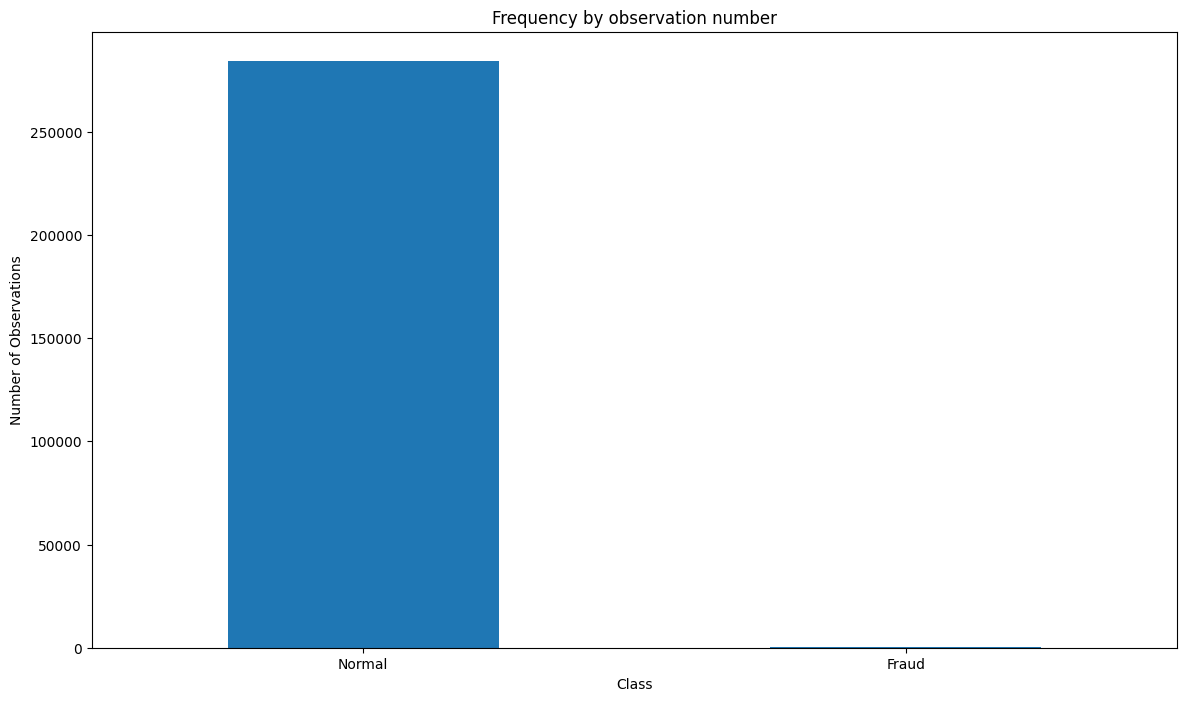

In [ ]:
# visualisasi jumlah kelas pada dataset
count_classes = pd.value_counts(df['Class'], sort = True)
count_classes.plot(kind = 'bar', rot=0, figsize=(14, 8))
plt.xticks(range(2), ["Normal","Fraud"])
plt.title("Frequency by observation number")
plt.xlabel("Class")
plt.ylabel("Number of Observations");

#  Splitting data menjadi fraud dan normal

In [ ]:
normal_df = df[df['Class']==0]
fraud_df = df[df['Class']==1]

In [ ]:
#statistika deskriptif fraud
fraud_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,...,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.0
mean,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,1.0
std,47835.365138,6.783687,4.291216,7.110937,2.873318,5.372468,1.858124,7.206773,6.797831,2.500896,...,3.869304,1.494602,1.579642,0.515577,0.797205,0.471679,1.376766,0.547291,256.683288,0.0
min,406.000000,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0
25%,41241.500000,-6.036063,1.188226,-8.643489,2.373050,-4.792835,-2.501511,-7.965295,-0.195336,-3.872383,...,0.041787,-0.533764,-0.342175,-0.436809,-0.314348,-0.259416,-0.020025,-0.108868,1.000000,1.0
50%,75568.500000,-2.342497,2.717869,-5.075257,4.177147,-1.522962,-1.424616,-3.034402,0.621508,-2.208768,...,0.592146,0.048434,-0.073135,-0.060795,0.088371,0.004321,0.394926,0.146344,9.250000,1.0
75%,128483.000000,-0.419200,4.971257,-2.276185,6.348729,0.214562,-0.413216,-0.945954,1.764879,-0.787850,...,1.244611,0.617474,0.308378,0.285328,0.456515,0.396733,0.826029,0.381152,105.890000,1.0
max,170348.000000,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,...,27.202839,8.361985,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0


In [ ]:
#statistika deskriptif fraud
normal_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,...,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.0
mean,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022,0.0
std,47484.015786,1.929814,1.636146,1.459429,1.399333,1.356952,1.329913,1.178812,1.161283,1.089372,...,0.716743,0.723668,0.621541,0.605776,0.520673,0.482241,0.399847,0.329570,250.105092,0.0
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-31.764946,-73.216718,-6.290730,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.0
25%,54230.000000,-0.917544,-0.599473,-0.884541,-0.850077,-0.689398,-0.766847,-0.551442,-0.208633,-0.640412,...,-0.228509,-0.542403,-0.161702,-0.354425,-0.317145,-0.327074,-0.070852,-0.052950,5.650000,0.0
50%,84711.000000,0.020023,0.064070,0.182158,-0.022405,-0.053457,-0.273123,0.041138,0.022041,-0.049964,...,-0.029821,0.006736,-0.011147,0.041082,0.016417,-0.052227,0.001230,0.011199,22.000000,0.0
75%,139333.000000,1.316218,0.800446,1.028372,0.737624,0.612181,0.399619,0.571019,0.326200,0.598230,...,0.185626,0.528407,0.147522,0.439869,0.350594,0.240671,0.090573,0.077962,77.050000,0.0
max,172792.000000,2.454930,18.902453,9.382558,16.875344,34.801666,73.301626,120.589494,18.709255,15.594995,...,22.614889,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,0.0


In [ ]:
# statistika deskriptif variabel ammount normal
normal_df.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [ ]:
# statistika deskriptif variabel ammount fraud
fraud_df.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


# Masuk ke tahap pemodelan

In [ ]:
from xgboost import XGBClassifier  # Import XGBoost
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

## preprocessing data

In [ ]:
X = df.drop(columns=['Class'])
y = df['Class']

In [ ]:
# normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42) # tesnya 20%

In [ ]:
X_train.shape

(227845, 30)

## pemodelan autoencoder

In [ ]:
input_dim = X_train.shape[1] # shape nya biar sama 30
encoding_dim = 15 # dimensi yang dipingin

In [ ]:
# mulai bangun model
autoencoder = Sequential([
    Dense(encoding_dim, activation='relu', input_dim=input_dim),
    Dense(input_dim, activation='sigmoid')
])

# Compile autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=256, shuffle=True, validation_split=0.2, verbose=0)

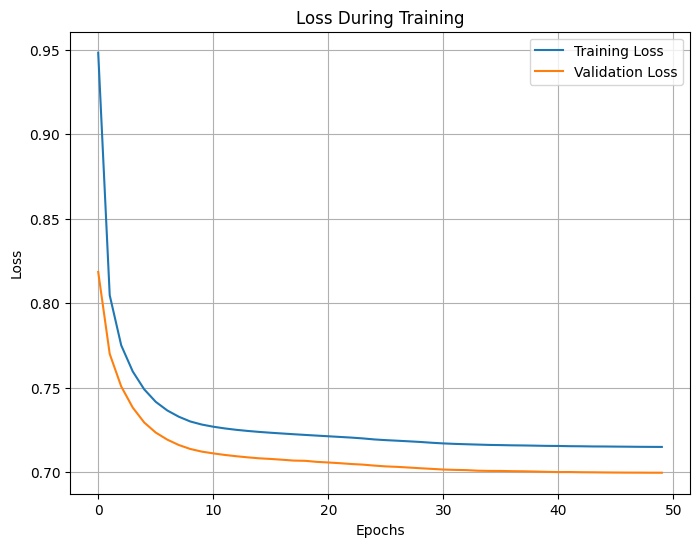

In [ ]:
# Plot loss dari history
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Extract features from the encoder
# encoder = Sequential(autoencoder.layers[:1])  # Ambil encoder saja
X_train_encoded = autoencoder.predict(X_train)
X_test_encoded = autoencoder.predict(X_test)

7121/7121 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [ ]:
X_train_encoded.shape

(227845, 30)

# klasifikasi XGBoost

In [ ]:
X_test_encoded.shape

(56962, 30)

In [ ]:
xgb = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))
xgb.fit(X_train_encoded, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_pred = xgb.predict(X_test_encoded)
y_pred_proba = xgb.predict_proba(X_test_encoded)[:, 1]

In [ ]:
# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.87      0.87        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56851    13]
 [   13    85]]
ROC-AUC Score: 0.9692355839353187


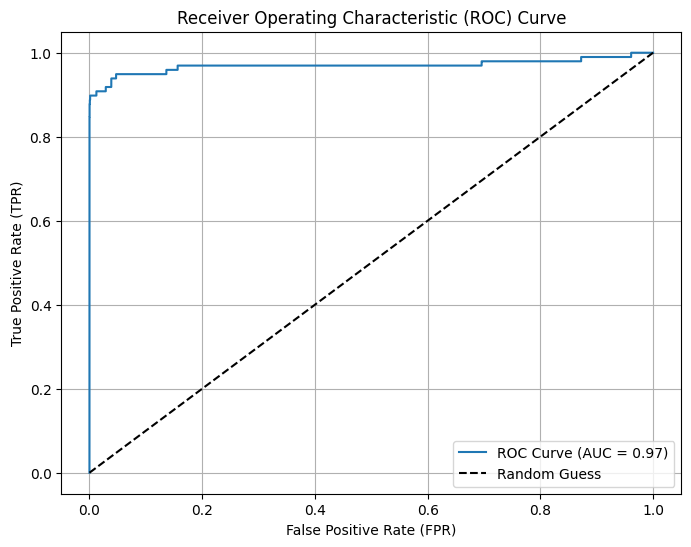

In [ ]:
# visualisasi ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')  # Garis diagonal sebagai baseline
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Callback

In [ ]:
from tensorflow.keras.callbacks import Callback
import time

class TimingCallback(Callback):
    def on_train_begin(self, logs=None):
        self.train_start_time = time.time()

    def on_train_end(self, logs=None):
        total_duration = time.time() - self.train_start_time
        print(f"Total training time: {total_duration:.2f} seconds.")

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.epoch_start_time
        print(f"Epoch {epoch + 1} completed in {duration:.2f} seconds.")



# TES 10

In [ ]:
input_dim = X_train.shape[1] # shape nya biar sama 30
encoding_dim = 10 # dimensi yang dipingin
# mulai bangun model
autoencoder2 = Sequential([
    Dense(encoding_dim, activation='relu', input_dim=input_dim),
    Dense(input_dim, activation='sigmoid')
])

# Compile autoencoder
autoencoder2.compile(optimizer='adam', loss='mse')
# Timing callback instance
timing_callback = TimingCallback()

# Train autoencoder with timing
history = autoencoder2.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,
    verbose=1,
    callbacks=[timing_callback]
)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
698/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0984Epoch 1 completed in 4.26 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.0961 - val_loss: 0.8722
Epoch 2/50
703/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8663Epoch 2 completed in 1.79 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8663 - val_loss: 0.8306
Epoch 3/50
709/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8523Epoch 3 completed in 2.10 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8522 - val_loss: 0.8096
Epoch 4/50
687/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8249Epoch 4 completed in 2.52 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8246 - val_loss: 0.7951
Epoch 5/50
686/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8014Epoch 5 completed in 1.24 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8015 - val_loss: 0.7848
Epoch 6/50
709/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7874Epoch 6 completed in 1.21 seconds.
713/713 ━━━━━━━━━━━

In [ ]:
X_train_encoded = autoencoder2.predict(X_train)
X_test_encoded = autoencoder2.predict(X_test)
xgb = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))
xgb.fit(X_train_encoded, y_train)
y_pred = xgb.predict(X_test_encoded)
y_pred_proba = xgb.predict_proba(X_test_encoded)[:, 1]
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

7121/7121 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56851    13]
 [   16    82]]
ROC-AUC Score: 0.9688040135863012


# TES 15

In [ ]:
input_dim = X_train.shape[1] # shape nya biar sama 30
encoding_dim = 15 # dimensi yang dipingin
# mulai bangun model
autoencoder3 = Sequential([
    Dense(encoding_dim, activation='relu', input_dim=input_dim),
    Dense(input_dim, activation='sigmoid')
])

# Compile autoencoder
autoencoder3.compile(optimizer='adam', loss='mse')
# Timing callback instance
timing_callback = TimingCallback()

# Train autoencoder with timing
history = autoencoder3.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,
    verbose=1,
    callbacks=[timing_callback]
)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
703/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0502Epoch 1 completed in 3.03 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.0487 - val_loss: 0.8167
Epoch 2/50
694/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8246Epoch 2 completed in 1.31 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8241 - val_loss: 0.7739
Epoch 3/50
712/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7820Epoch 3 completed in 1.96 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7820 - val_loss: 0.7561
Epoch 4/50
680/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7501Epoch 4 completed in 2.38 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7508 - val_loss: 0.7436
Epoch 5/50
682/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7636Epoch 5 completed in 1.92 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7632 - val_loss: 0.7344
Epoch 6/50
685/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7429Epoch 6 completed in 1.30 seconds.
713/713 ━━━━━━━━━━━

In [ ]:
X_train_encoded = autoencoder3.predict(X_train)
X_test_encoded = autoencoder3.predict(X_test)
xgb = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))
xgb.fit(X_train_encoded, y_train)
y_pred = xgb.predict(X_test_encoded)
y_pred_proba = xgb.predict_proba(X_test_encoded)[:, 1]
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

7121/7121 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.87      0.88        98

    accuracy                           1.00     56962
   macro avg       0.95      0.93      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56854    10]
 [   13    85]]
ROC-AUC Score: 0.9736130172384092


# TES 20

In [ ]:
input_dim = X_train.shape[1] # shape nya biar sama 30
encoding_dim = 20 # dimensi yang dipingin
# mulai bangun model
autoencoder4 = Sequential([
    Dense(encoding_dim, activation='relu', input_dim=input_dim),
    Dense(input_dim, activation='sigmoid')
])

# Compile autoencoder
autoencoder4.compile(optimizer='adam', loss='mse')
# Timing callback instance
timing_callback = TimingCallback()

# Train autoencoder with timing
history = autoencoder4.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,
    verbose=1,
    callbacks=[timing_callback]
)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
708/713 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0230Epoch 1 completed in 4.87 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.0221 - val_loss: 0.7799
Epoch 2/50
682/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7675Epoch 2 completed in 3.26 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7673 - val_loss: 0.7286
Epoch 3/50
709/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7359Epoch 3 completed in 2.95 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7359 - val_loss: 0.7123
Epoch 4/50
711/713 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7183Epoch 4 completed in 2.95 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7183 - val_loss: 0.7021
Epoch 5/50
675/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7368Epoch 5 completed in 1.32 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7355 - val_loss: 0.6944
Epoch 6/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7011Epoch 6 completed in 2.54 seconds.
713/713 ━━━━━━━━━━━

In [ ]:
X_train_encoded = autoencoder4.predict(X_train)
X_test_encoded = autoencoder4.predict(X_test)
xgb = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))
xgb.fit(X_train_encoded, y_train)
y_pred = xgb.predict(X_test_encoded)
y_pred_proba = xgb.predict_proba(X_test_encoded)[:, 1]
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

7121/7121 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56851    13]
 [   16    82]]
ROC-AUC Score: 0.9700333161542614


# Tes 25

In [ ]:
input_dim = X_train.shape[1] # shape nya biar sama 30
encoding_dim = 25 # dimensi yang dipingin
# mulai bangun model
autoencoder5 = Sequential([
    Dense(encoding_dim, activation='relu', input_dim=input_dim),
    Dense(input_dim, activation='sigmoid')
])

# Compile autoencoder
autoencoder5.compile(optimizer='adam', loss='mse')
# Timing callback instance
timing_callback = TimingCallback()

# Train autoencoder with timing
history = autoencoder5.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,
    verbose=1,
    callbacks=[timing_callback]
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


690/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9925Epoch 1 completed in 2.14 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9890 - val_loss: 0.7513
Epoch 2/50
697/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7434Epoch 2 completed in 2.26 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7433 - val_loss: 0.7076
Epoch 3/50
699/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7272Epoch 3 completed in 1.34 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7269 - val_loss: 0.6913
Epoch 4/50
705/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7012Epoch 4 completed in 3.28 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7012 - val_loss: 0.6810
Epoch 5/50
691/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7042Epoch 5 completed in 1.72 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7038 - val_loss: 0.6741
Epoch 6/50
707/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6910Epoch 6 completed in 2.06 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
X_train_encoded = autoencoder5.predict(X_train)
X_test_encoded = autoencoder5.predict(X_test)
xgb = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))
xgb.fit(X_train_encoded, y_train)
y_pred = xgb.predict(X_test_encoded)
y_pred_proba = xgb.predict_proba(X_test_encoded)[:, 1]
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

7121/7121 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.82      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56853    11]
 [   18    80]]
ROC-AUC Score: 0.9849914906170685


# coba - coba

In [ ]:
input_dim = X_train.shape[1] # shape nya biar sama 30
autoencoder6 = Sequential([
    Dense(25, activation='relu', input_dim=input_dim),  # Layer pertama 25 -> 20
    Dense(20, activation='relu'),                       # Layer kedua 20 -> 15
    Dense(15, activation='relu'),                       # Layer ketiga 15 -> 10 (Bottleneck)
    Dense(10, activation='relu'),

    # Decoder
    Dense(10, activation='relu'),
    Dense(15, activation='relu'),                       # Layer keempat 10 -> 15
    Dense(20, activation='relu'),                       # Layer kelima 15 -> 20
    Dense(25, activation='relu'),
    Dense(input_dim, activation='sigmoid')
])

autoencoder6.compile(optimizer='adam', loss='mse')

history = autoencoder6.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,
    verbose=1,
    callbacks=[timing_callback]
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
712/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0526Epoch 1 completed in 5.30 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.0524 - val_loss: 0.9180
Epoch 2/50
699/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9050Epoch 2 completed in 4.57 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.9051 - val_loss: 0.8860
Epoch 3/50
702/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9058Epoch 3 completed in 2.58 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9057 - val_loss: 0.8715
Epoch 4/50
703/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8636Epoch 4 completed in 1.92 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8637 - val_loss: 0.8475
Epoch 5/50
704/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8438Epoch 5 completed in 2.68 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8440 - val_loss: 0.8377
Epoch 6/50
707/713 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8543Epoch 6 completed in 3.93 seconds.
713/713 ━━━━━━━━━━━

In [ ]:
X_train_encoded = autoencoder6.predict(X_train)
X_test_encoded = autoencoder6.predict(X_test)
xgb = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))
xgb.fit(X_train_encoded, y_train)
y_pred = xgb.predict(X_test_encoded)
y_pred_proba = xgb.predict_proba(X_test_encoded)[:, 1]
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

7121/7121 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56846    18]
 [   19    79]]
ROC-AUC Score: 0.9365220131384011


In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

### Visualisasi dan tes waktu

In [ ]:
#autoencoder + xgboost
#2 menit 3 detik
input_dim = X_train.shape[1] # shape nya biar sama 30
encoding_dim = 20 # dimensi yang dipingin
# mulai bangun model
autoencoder20 = Sequential([
    Dense(encoding_dim, activation='relu', input_dim=input_dim),
    Dense(input_dim, activation='sigmoid')
])

# Compile autoencoder
autoencoder20.compile(optimizer='adam', loss='mse')
# Timing callback instance
timing_callback = TimingCallback()

# Train autoencoder with timing
history = autoencoder20.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,
    verbose=1,
    callbacks=[timing_callback]
)
X_train_encoded = autoencoder20.predict(X_train)
X_test_encoded = autoencoder20.predict(X_test)
xgb = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))
xgb.fit(X_train_encoded, y_train)
y_pred = xgb.predict(X_test_encoded)
y_pred_proba = xgb.predict_proba(X_test_encoded)[:, 1]
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
697/713 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0374Epoch 1 completed in 5.36 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.0347 - val_loss: 0.7842
Epoch 2/50
712/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7733Epoch 2 completed in 2.37 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7733 - val_loss: 0.7335
Epoch 3/50
673/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7254Epoch 3 completed in 1.36 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7261 - val_loss: 0.7140
Epoch 4/50
707/713 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7279Epoch 4 completed in 1.81 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7279 - val_loss: 0.7016
Epoch 5/50
694/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7045Epoch 5 completed in 2.08 seconds.
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7048 - val_loss: 0.6936
Epoch 6/50
708/713 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7139Epoch 6 completed in 1.91 seconds.
713/713 ━━━━━━━━━━━

In [ ]:
#xgboost biasa
# 9 detik
xgb = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))
xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_test)
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56853    11]
 [   16    82]]
ROC-AUC Score: 0.9682378578893572


autoencoder + xgboost :
accuracy ROC = 0.977
lama train dan hasil akurasi = 2 menit 3 detik

Xgboost biasa :
accuracy ROC = 0.968
lama train dan hasil akurasi = 9 detik

Autoencoder biasa :
accuracy ROC = 0.942
lama train dan hasil akurasi = 6 menit 20 detik

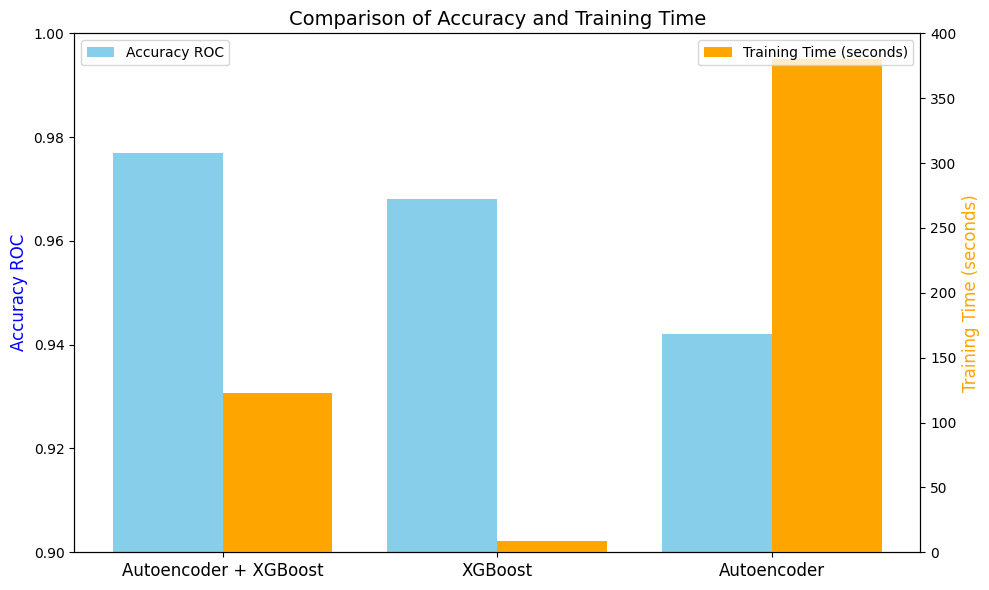

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data penelitian
methods = ["Autoencoder + XGBoost", "XGBoost", "Autoencoder"]
accuracy_roc = [0.977, 0.968, 0.942]  # Accuracy ROC
train_time = [123, 9, 380]  # Lama training dalam detik

# Mengatur posisi untuk bar
x = np.arange(len(methods))

# Membuat diagram
fig, ax1 = plt.subplots(figsize=(10, 6))

# Diagram untuk accuracy ROC
ax1.bar(x - 0.2, accuracy_roc, width=0.4, label='Accuracy ROC', color='skyblue')
ax1.set_ylabel('Accuracy ROC', fontsize=12, color='blue')
ax1.set_ylim(0.9, 1.0)

# Menambahkan axis kedua untuk lama training
ax2 = ax1.twinx()
ax2.bar(x + 0.2, train_time, width=0.4, label='Training Time (seconds)', color='orange')
ax2.set_ylabel('Training Time (seconds)', fontsize=12, color='orange')
ax2.set_ylim(0, 400)

# Menambahkan label, judul, dan legenda
ax1.set_xticks(x)
ax1.set_xticklabels(methods, fontsize=12)
plt.title('Comparison of Accuracy and Training Time', fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Menampilkan diagram
plt.tight_layout()
plt.show()
